### CD8 Tem Milo Differential Abundance Analysis: Age-by-Sex Interaction
*Dataset: PICA Batch001–Batch007 (PICA0001–PICA0128)* \
*Analysis: CD8 Tem neighbourhood-level age-by-sex interaction modelling using MiloR*

#### Aim
This notebook tests for age-by-sex interaction effects within CD8 Tem neighbourhoods using MiloR.

Neighbourhood abundance is modelled as a function of age, sex and their interaction to identify regions of the CD8 Tem manifold that exhibit sex-specific ageing trajectories.

In [48]:
library(zellkonverter)
library(SingleCellExperiment)
library(miloR)
library(scater)
library(scran)
library(Matrix)
library(dplyr)
library (ggplot2)
library(gridExtra)

set.seed(33)

outdir = "/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/03_milo"



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:BiocGenerics’:

    combine




In [2]:
cd8_sce<- readH5AD("/scratch/user/s4575250/BIOX7014_Thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_miloR.h5ad")

In [ ]:
# Inspect object structure and dimensions
print(cd8_sce)
print(dim(cd8_sce))

print(colnames(colData(cd8_sce)))
print(head(as.data.frame(colData(cd8_sce))))

print(assayNames(cd8_sce))

class: SingleCellExperiment 
dim: 38606 265568 
metadata(0):
assays(1): X
rownames(38606): DDX11L2 MIR1302-2HG ... ENSG00000278817
  ENSG00000277196
rowData names(6): gene_ids feature_types ... ribo hb
colnames(265568):
  20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGCTAGGTC
  20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAGCAGGCTTCA
  ...
  20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTTGTCTTCGCGTGCA
  20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTTGTGCAGAAGCTAA
colData names(5): pica_id ageyrs sex batch
  pica_cell_type_complete_01_gdT_corrected
reducedDimNames(2): X_scVI X_umap
mainExpName: NULL
altExpNames(0):
[1]  38606 265568
[1] "pica_id"                                 
[2] "ageyrs"                                  
[3] "sex"                                     
[4] "batch"                                   
[5] "pica_cell_type_complete_01_gdT_corrected"
                                                                    pica_id
20240918_WGS_20

In [4]:
# Check available annotations
table(cd8_sce$pica_cell_type_complete_01_gdT_corrected)


CD8 GZMK+ naive/Tcm             CD8 Tem       CD8 naive/Tcm 
              39689               50185              175694 

## Subset to CD8 Tem and clean metadata

In [ ]:
# Subset to CD8 Tem Population
cd8_tem <- cd8_sce[
  ,
  cd8_sce$pica_cell_type_complete_01_gdT_corrected == "CD8 Tem"
]

cd8_tem

dim(cd8_tem)

table(cd8_tem$pica_cell_type_complete_01_gdT_corrected)

class: SingleCellExperiment 
dim: 38606 50185 
metadata(0):
assays(1): X
rownames(38606): DDX11L2 MIR1302-2HG ... ENSG00000278817
  ENSG00000277196
rowData names(6): gene_ids feature_types ... ribo hb
colnames(50185):
  20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGCTAGGTC
  20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCCCAGAGTAATG
  ...
  20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTGTACATCATGCCTT
  20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTTGCGCCAGCAGGCA
colData names(5): pica_id ageyrs sex batch
  pica_cell_type_complete_01_gdT_corrected
reducedDimNames(2): X_scVI X_umap
mainExpName: NULL
altExpNames(0):

[1] 38606 50185


CD8 GZMK+ naive/Tcm             CD8 Tem       CD8 naive/Tcm 
                  0               50185                   0 

In [7]:
table(colData(cd8_tem)$sex)
table(colData(cd8_tem)$batch)
summary(colData(cd8_tem)$ageyrs)
length(unique(colData(cd8_tem)$pica_id))
table(colData(cd8_tem)$pica_id)[1:10]


Female   Male 
 19092  31093 


Batch01 Batch02 Batch03 Batch04 Batch05 Batch06 Batch07 
    444    9700   10687    6742    8030    8889    5693 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.050   4.760   7.190   8.289  13.020  17.030 

[1] 127


PICA0001 PICA0002 PICA0003 PICA0004 PICA0005 PICA0006 PICA0007 PICA0008 
     174       14       29       62       92        0       73     1067 
PICA0009 PICA0010 
    1097        1 

In [ ]:
# check for missing values
colSums(is.na(colData(cd8_tem)[, c("pica_id", "ageyrs", "sex", "batch")]))

[1] 0 0 0 0

In [10]:
#clean metadata
meta <- as.data.frame(colData(cd8_tem))
meta$pica_id <- as.character(meta$pica_id)
meta$ageyrs <- as.numeric(meta$ageyrs)
meta$sex <- factor(meta$sex)
meta$batch <- factor(meta$batch)

# define reference level
meta$sex <- relevel(meta$sex, ref = "Female")

# put cleaned metadata back into object
colData(cd8_tem) <- S4Vectors::DataFrame(meta)


## Build milo object

In [ ]:
# Initialise Milo object from the CD8 Tem SingleCellExperiment
milo <- Milo(cd8_tem)

latent_dim <- min(20, ncol(reducedDim(milo, "X_scVI")))

# Construct k-nearest neighbour graph using the scVI latent space
milo <- buildGraph(
  milo,
  k = 30,
  d = latent_dim,
  reduced.dim = "X_scVI"
)

Constructing kNN graph with k:30



In [ ]:
# Define Milo neighbourhoods from the kNN graph
milo <- makeNhoods(
  milo,
  prop = 0.1,
  k = 30,
  d = latent_dim,
  refined = TRUE,
  reduced_dims = "X_scVI"
)

Checking valid object

Running refined sampling with reduced_dim



[1] 50185  4651

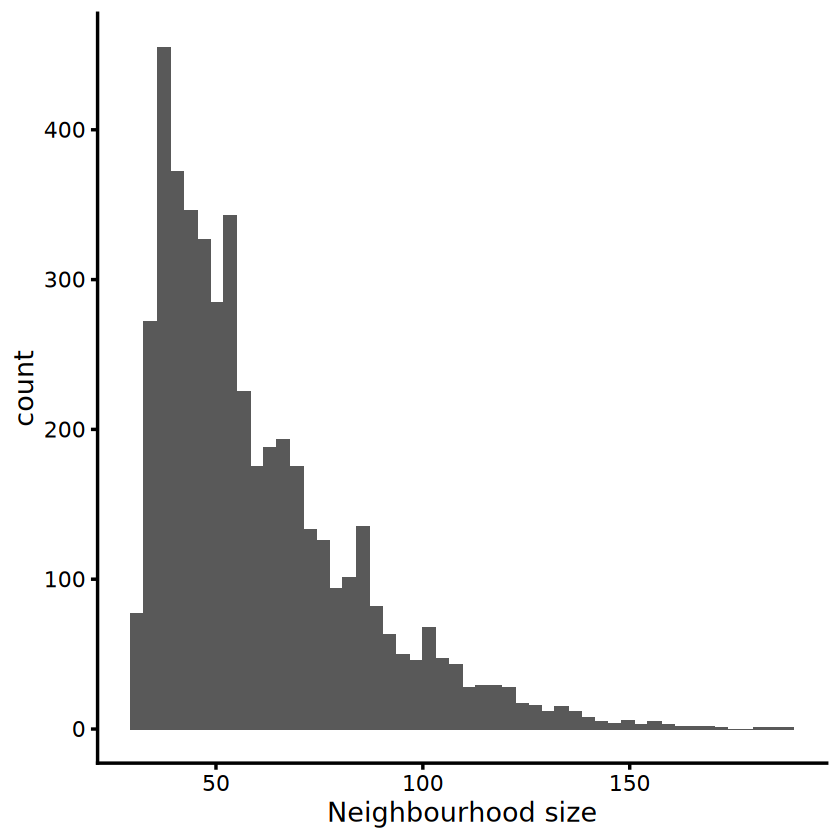

In [13]:
dim(nhoods(milo))
plotNhoodSizeHist(milo)

In [14]:
t1 <- Sys.time()
milo <- calcNhoodDistance(
  milo,
  d = 20,
  reduced.dim = "X_scVI"
)
t2 <- Sys.time()
print(difftime(t2, t1, units = "mins"))

'as(<dgTMatrix>, "dgCMatrix")' is deprecated.
Use 'as(., "CsparseMatrix")' instead.
See help("Deprecated") and help("Matrix-deprecated").



Time difference of 18.49421 mins


In [ ]:
saveRDS(milo, "/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/03_milo/cd8_tem_milo_age_sex_with_distances.rds")

## Count cells and build donor-level design

In [17]:
# count cells per sample
milo <- countCells(
  milo,
  meta.data = as.data.frame(colData(milo)),
  samples = "pica_id"
)

print(dim(nhoodCounts(milo)))

Checking meta.data validity

Counting cells in neighbourhoods



[1] 4651  127


In [22]:
library(dplyr)
# build donor-level design dataframe
design_df <- as.data.frame(colData(milo))

design_df <- dplyr::select(
  design_df,
  pica_id,
  ageyrs,
  sex,
  batch
)

design_df <- distinct(design_df)

rownames(design_df) <- design_df$pica_id

design_df <- design_df[colnames(nhoodCounts(milo)), , drop = FALSE]


Attaching package: ‘dplyr’


The following object is masked from ‘package:Biobase’:

    combine


The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:matrixStats’:

    count




The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
# Ensure correct types after subsetting
design_df$sex <- factor(design_df$sex)
design_df$batch <- factor(design_df$batch)
design_df$sex <- relevel(design_df$sex, ref = "Female")

In [24]:
cat("\n===== FINAL DESIGN DF =====\n")
print(head(design_df))

cat("\n===== FINAL MODEL MATRIX COLUMNS =====\n")
mm <- model.matrix(~ ageyrs * sex + batch, data = design_df)
print(colnames(mm))


===== FINAL DESIGN DF =====
          pica_id ageyrs    sex   batch
PICA0022 PICA0022  12.72   Male Batch02
PICA0020 PICA0020  15.52   Male Batch02
PICA0023 PICA0023   4.80   Male Batch02
PICA0009 PICA0009   4.76 Female Batch02
PICA0008 PICA0008   9.70 Female Batch02
PICA0010 PICA0010   0.07 Female Batch02

===== FINAL MODEL MATRIX COLUMNS =====
 [1] "(Intercept)"    "ageyrs"         "sexMale"        "batchBatch02"  
 [5] "batchBatch03"   "batchBatch04"   "batchBatch05"   "batchBatch06"  
 [9] "batchBatch07"   "ageyrs:sexMale"


In [ ]:
# Build model matrix and make syntactically valid names for edgeR::makeContrasts
mm <- model.matrix(~ ageyrs * sex + batch, data = design_df)

colnames(mm)

[1] "(Intercept)"    "ageyrs"         "sexMale"        "batchBatch02"  
 [5] "batchBatch03"   "batchBatch04"   "batchBatch05"   "batchBatch06"  
 [9] "batchBatch07"   "ageyrs:sexMale"

In [37]:
colnames(mm) <- make.names(colnames(mm))

colnames(mm)

[1] "X.Intercept."   "ageyrs"         "sexMale"        "batchBatch02"  
 [5] "batchBatch03"   "batchBatch04"   "batchBatch05"   "batchBatch06"  
 [9] "batchBatch07"   "ageyrs.sexMale"

## Run CD8 Tem age x sex milo interaction

In [38]:
da_cd8_interaction <- testNhoods(
  milo,
  design = mm,
  design.df = design_df,
  model.contrasts = "ageyrs.sexMale",
  fdr.weighting = "k-distance",
  robust = TRUE,
  reduced.dim = "X_scVI"
)

Using TMM normalisation

Running with model contrasts

Performing spatial FDR correction with k-distance weighting



In [39]:
cat("\n===== DA RESULTS HEAD =====\n")
print(head(da_cd8_interaction))

cat("\n===== SIGNIFICANT NHOODS (SpatialFDR < 0.1) =====\n")
print(table(da_cd8_interaction$SpatialFDR < 0.1, useNA = "ifany"))



===== DA RESULTS HEAD =====
         logFC   logCPM         F     PValue       FDR Nhood SpatialFDR
1  0.181013373 10.99932 5.6692812 0.01726487 0.2317535     1  0.2372425
2  0.137072234 10.84381 3.0184025 0.20924031 0.5910090     2  0.5942397
3  0.056156225 10.94807 0.4938780 0.48220279 0.8303314     3  0.8306995
4 -0.045160726 10.76481 0.4650094 0.49529236 0.8404249     4  0.8411087
5  0.003076003 10.81402 0.5525273 0.51151128 0.8511865     5  0.8519754
6  0.130264382 10.89320 3.0887826 0.07883433 0.4124392     6  0.4172436

===== SIGNIFICANT NHOODS (SpatialFDR < 0.1) =====

FALSE  TRUE 
 4567    84 


In [43]:
write.csv(
  da_cd8_interaction,
  file.path("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/03_milo/cd8_tem_age_sex_interaction_milo_results.csv"),
  row.names = TRUE
)

## Visualization

In [52]:
# create plotting dataframe
df_plot <- da_cd8_interaction

df_plot$sig <- df_plot$SpatialFDR < 0.1

# Since this is CD8 Tem-only Milo, all neighbourhoods are CD8 Tem
df_plot$nhood_annotation <- "CD8 Tem"

df_plot$nhood_annotation <- factor(
  df_plot$nhood_annotation,
  levels = "CD8 Tem"
)

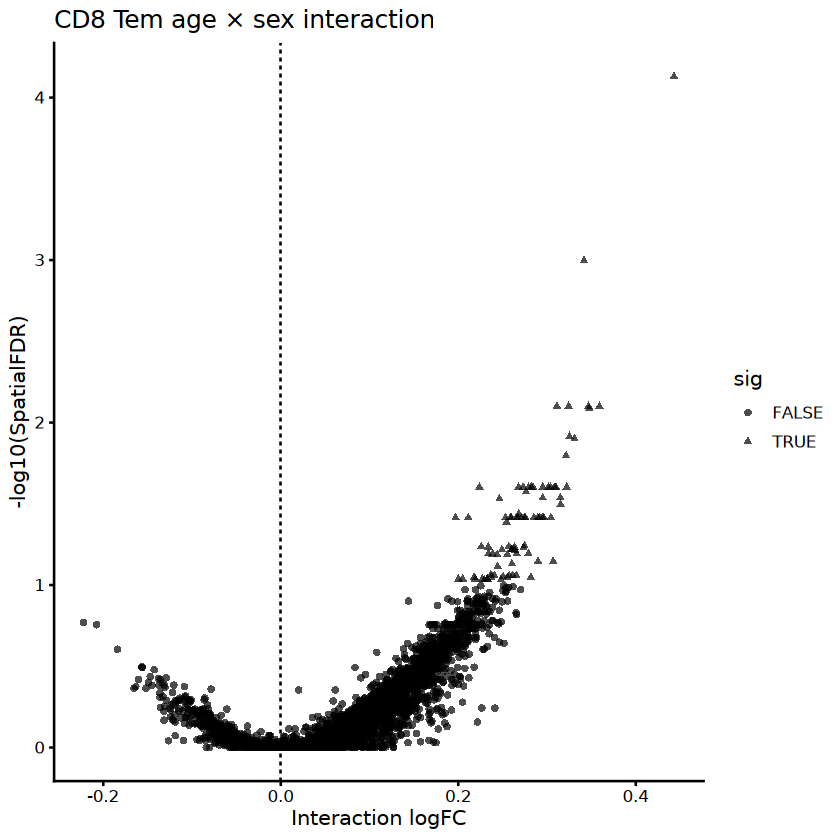

In [ ]:
# plot interaction plot
p_volcano_like <- ggplot(
  df_plot,
  aes(
    x = logFC,
    y = -log10(SpatialFDR)
  )
) +
  geom_point(
    aes(shape = sig),
    alpha = 0.7,
    size = 1.5
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    title = "CD8 Tem age × sex interaction",
    x = "Interaction logFC",
    y = "-log10(SpatialFDR)"
  ) +
  theme_classic(base_size = 12)

print(p_volcano_like)

In [57]:
table(da_cd8_interaction$SpatialFDR < 0.1)

summary(da_cd8_interaction$logFC)


FALSE  TRUE 
 4567    84 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-0.22214  0.01927  0.07340  0.07297  0.12527  0.44313 

In [69]:
write.csv(
  df_plot,
  file.path("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/03_milo/cd8_tem_milo_all_annotated_neighbourhoods.csv"),
  row.names = FALSE
)

Adding nhood effect sizes to neighbourhood graph attributes



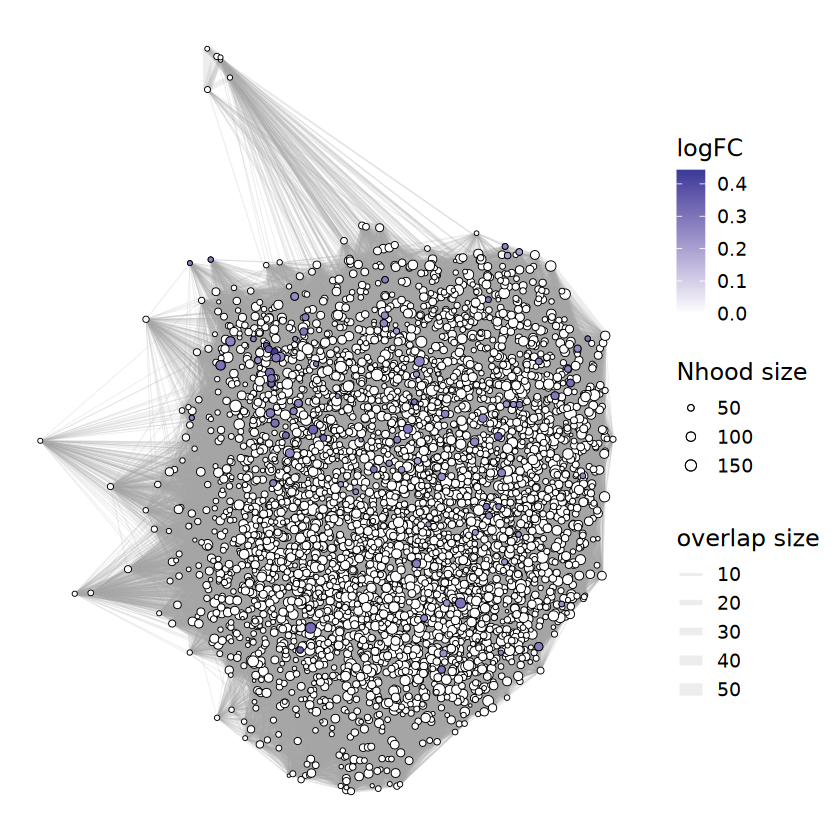

In [58]:
# neighbourhood DA UMAP
milo <- buildNhoodGraph(milo)
  plotNhoodGraphDA(
    milo,
    da_cd8_interaction,
    alpha = 0.1,
    layout = "X_umap"
  )

In [ ]:
# Extract neighbourhoods with significant age-by-sex interaction effects
top_sig_nhoods <- df_plot %>%
  dplyr::filter(SpatialFDR < 0.1) %>%
  dplyr::arrange(SpatialFDR, desc(abs(logFC))) %>%
  dplyr::select(
    logFC,
    PValue,
    SpatialFDR
  ) %>%
  head(20)

print(top_sig_nhoods)

write.csv(
  top_sig_nhoods,
  file.path("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/03_milo/cd8_tem_milo_top30_significant_neighbourhoods.csv"),
  row.names = FALSE
)

         logFC       PValue   SpatialFDR
1895 0.4431272 1.532547e-08 7.413969e-05
2459 0.3416570 4.081287e-07 1.007739e-03
2023 0.3590492 4.770924e-06 7.950069e-03
3271 0.3466876 8.787043e-06 7.950069e-03
590  0.3243246 6.538776e-06 7.950069e-03
4503 0.3111124 9.844114e-06 7.950069e-03
1404 0.3474252 1.187257e-05 8.203158e-03
515  0.3253030 1.994885e-05 1.218751e-02
437  0.3309246 2.345413e-05 1.258066e-02
782  0.3214584 3.320995e-05 1.599848e-02
2121 0.3221697 9.511150e-05 2.495744e-02
4385 0.3099331 1.138946e-04 2.495744e-02
4238 0.3088265 8.825322e-05 2.495744e-02
3679 0.3039418 1.081741e-04 2.495744e-02
3218 0.3015770 8.720626e-05 2.495744e-02
2305 0.2952292 8.932661e-05 2.495744e-02
33   0.2841470 7.992881e-05 2.495744e-02
2379 0.2823078 7.306164e-05 2.495744e-02
774  0.2792287 8.302098e-05 2.495744e-02
3508 0.2731274 1.096440e-04 2.495744e-02


In [ ]:
# Rank significant neighbourhoods by absolute interaction effect size
top_interaction <- df_plot %>%
  dplyr::filter(sig) %>%
  dplyr::arrange(desc(abs(logFC))) %>%
  head(10)

print(
  top_interaction[, c("logFC", "SpatialFDR")]
)

write.csv(
  top_interaction,
  file.path("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/03_milo/cd8_tem_milo_top_enriched_neighbourhoods.csv"),
  row.names = FALSE
)



         logFC   SpatialFDR
1895 0.4431272 7.413969e-05
2023 0.3590492 7.950069e-03
1404 0.3474252 8.203158e-03
3271 0.3466876 7.950069e-03
2459 0.3416570 1.007739e-03
437  0.3309246 1.258066e-02
515  0.3253030 1.218751e-02
590  0.3243246 7.950069e-03
2121 0.3221697 2.495744e-02
782  0.3214584 1.599848e-02
